In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
#DATA OVERVIEW AND CLEANING
df = pd.read_csv("Sample - Superstore_cleaned.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.head())
print("Dataset shape:", df.shape)
df.info()
df.describe()



   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


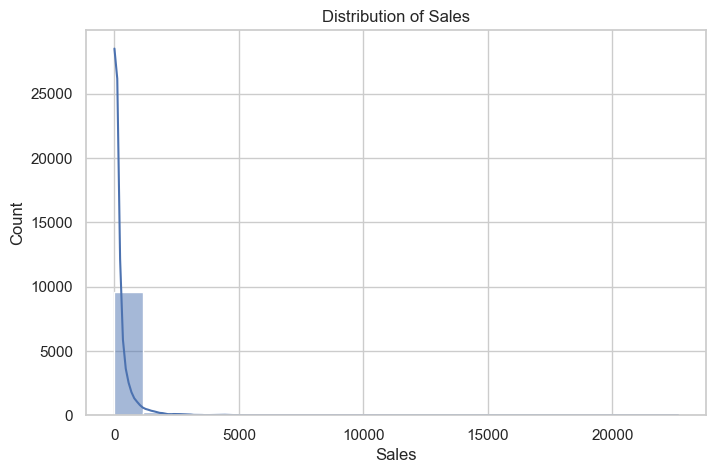

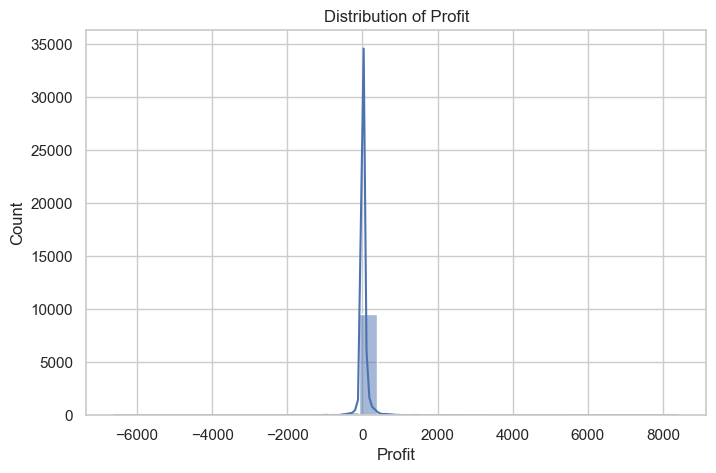

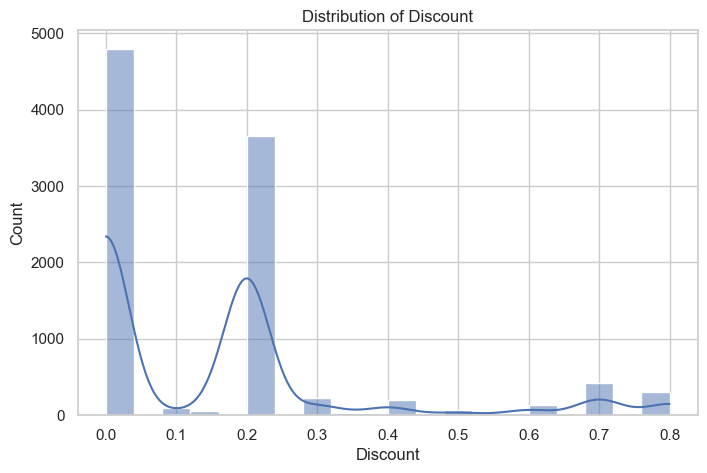

In [3]:
#EDA
#sales Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title("Distribution of Sales")
plt.show()

#Profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=30, kde=True)
plt.title("Distribution of Profit")
plt.show()

#Discount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Discount'], bins=20, kde=True)
plt.title("Distribution of Discount")
plt.show()



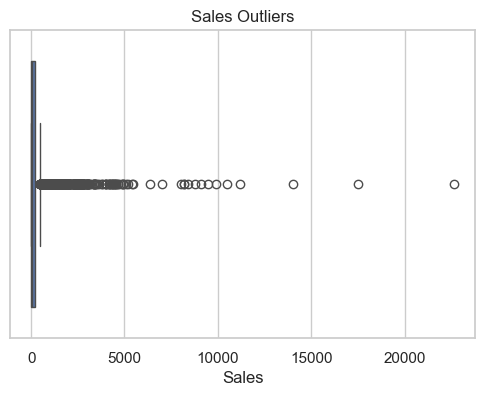

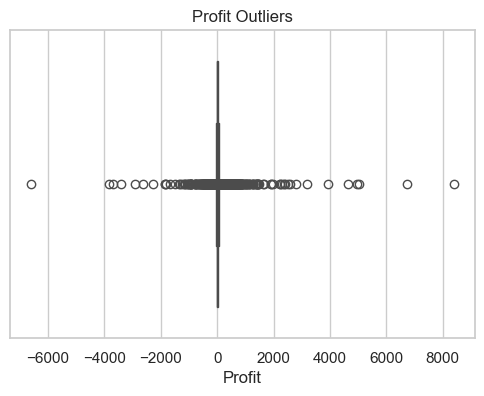

In [5]:
#Outlier Detection
#Sales Outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

#Profit Outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Profit'])
plt.title("Profit Outliers")
plt.show()


                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


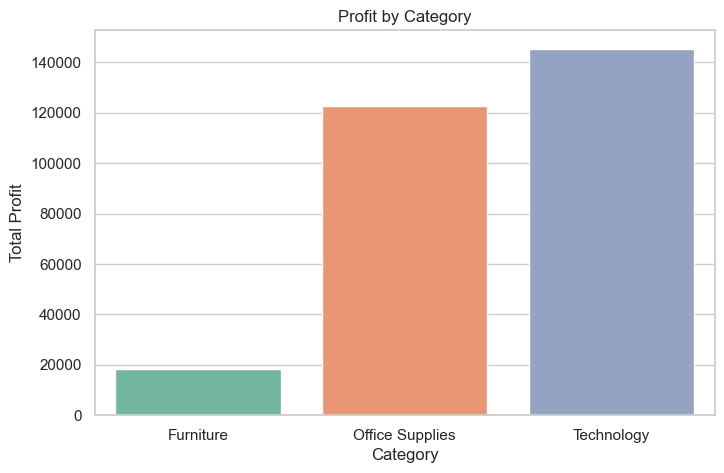

In [6]:
#1.Which categories generate the most profit?
category_profit = df.groupby('Category')[['Sales', 'Profit']].sum()
print(category_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=category_profit.index, y=category_profit['Profit'],hue=category_profit.index,
            palette="Set2",legend=False)
plt.title("Profit by Category")
plt.ylabel("Total Profit")
plt.show()



              Profit
Region              
Central   39706.3625
East      91522.7800
South     46749.4303
West     108418.4489


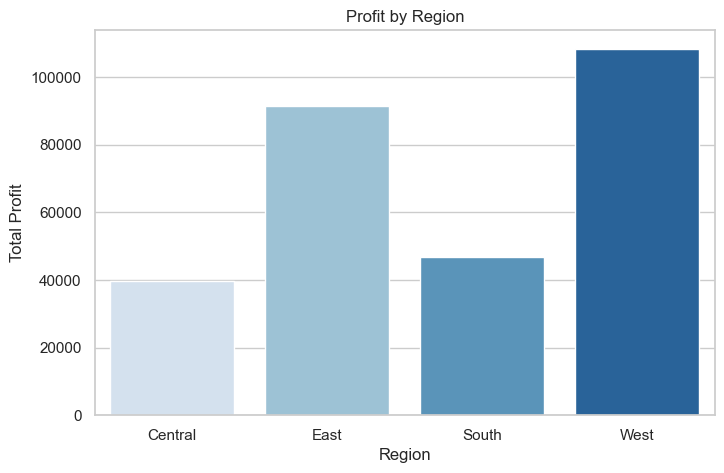

In [7]:
#2.Which regions are loss-making?
region_profit = df.groupby('Region')[['Profit']].sum()
print(region_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index, y=region_profit['Profit'],hue=region_profit.index,
            palette='Blues',legend=False)
plt.title("Profit by Region")
plt.ylabel("Total Profit")
plt.show()


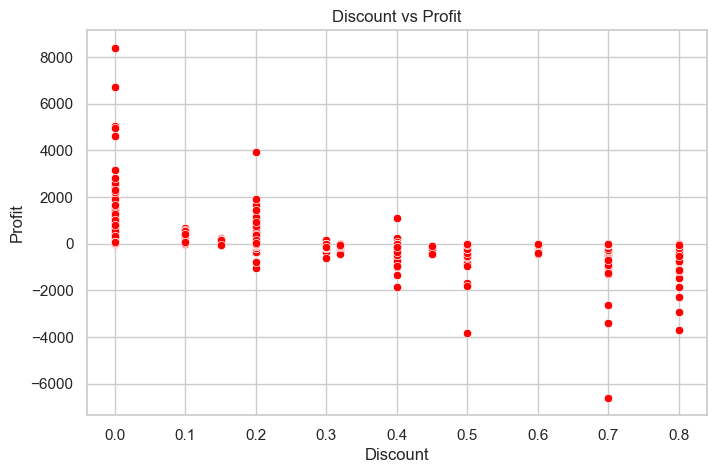

In [8]:
#3.How does discount affect profit?
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, color='red')
plt.title("Discount vs Profit")
plt.show()


                  Profit
Segment                 
Consumer     134119.2092
Corporate     91979.1340
Home Office   60298.6785


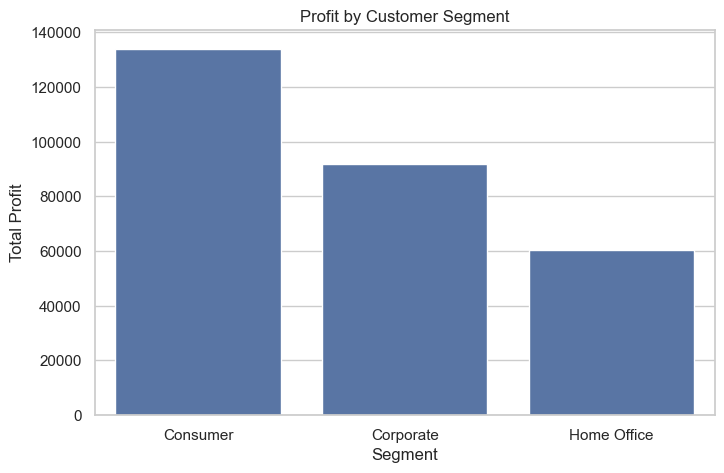

In [9]:
#4.Are there specific segments causing losses?
segment_profit = df.groupby('Segment')[['Profit']].sum()
print(segment_profit)

plt.figure(figsize=(8,5))
sns.barplot(x=segment_profit.index, y=segment_profit['Profit'])
plt.title("Profit by Customer Segment")
plt.ylabel("Total Profit")
plt.show()


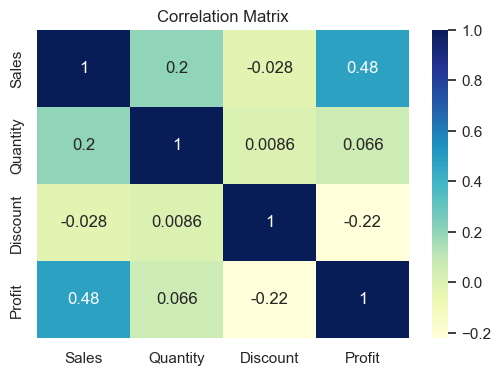

In [10]:
#5.What patterns lead to low-profit orders?
numeric_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
plt.title("Correlation Matrix")
plt.show()



                   Sales
Order Month             
2014-01       14236.8950
2014-02        4519.8920
2014-03       55691.0090
2014-04       28295.3450
2014-05       23648.2870
2014-06       34595.1276
2014-07       33946.3930
2014-08       27909.4685
2014-09       81777.3508
2014-10       31453.3930
2014-11       78628.7167
2014-12       69545.6205
2015-01       18174.0756
2015-02       11951.4110
2015-03       38726.2520
2015-04       34195.2085
2015-05       30131.6865
2015-06       24797.2920
2015-07       28765.3250
2015-08       36898.3322
2015-09       64595.9180
2015-10       31404.9235
2015-11       75972.5635
2015-12       74919.5212
2016-01       18542.4910
2016-02       22978.8150
2016-03       51715.8750
2016-04       38750.0390
2016-05       56987.7280
2016-06       40344.5340
2016-07       39261.9630
2016-08       31115.3743
2016-09       73410.0249
2016-10       59687.7450
2016-11       79411.9658
2016-12       96999.0430
2017-01       43971.3740
2017-02       20301.1334


<Figure size 1000x500 with 0 Axes>

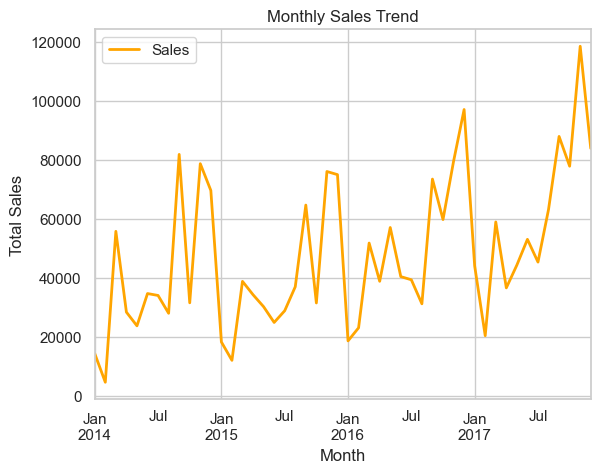

In [11]:
#6.Are there any seasonal or monthly sales trends?

df['Order Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Order Month')[['Sales']].sum()

print(monthly_sales)

plt.figure(figsize=(10,5))
monthly_sales.plot(color='orange',linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


In [3]:
#MACHINE LEARNING MODEL FOR RISK PREDICTION(XGBoost)
#create target variable(Risk)
df['Risk']=df['Profit'].apply(lambda x:1 if x<=0 else 0)
print(df[['Profit','Risk']].head())


     Profit  Risk
0   41.9136     0
1  219.5820     0
2    6.8714     0
3 -383.0310     1
4    2.5164     0


In [ ]:
#Spliting Training & Testing Data
X=df[['Sales','Discount','Quantity','Category','Region']]
y=df['Risk']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
X_train['Category']=le1.fit_transform(X_train['Category'])
X_test['Category']=le1.transform(X_test['Category'])

le2=LabelEncoder()
X_train['Region']=le2.fit_transform(X_train['Region'])
X_test['Region']=le2.transform(X_test['Region'])








In [5]:
#XGBoost
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred[:10])


[1 0 0 1 1 0 1 0 1 0]


In [6]:
from sklearn.metrics import accuracy_score, precision_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)

Accuracy: 0.9484742371185593
Precision: 0.9228395061728395


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(le1, open("le1.pkl", "wb"))
pickle.dump(le2, open("le2.pkl", "wb"))


In [8]:
model = pickle.load(open("model.pkl", "rb"))

In [9]:
df['Risk'].value_counts()

Risk
0    8058
1    1936
Name: count, dtype: int64